In [2]:
import pandas as pd

# Construct the relative path to the CSV file
file_path = '../data/interim/cleaning_data/Data/tags-goodreads-english-popular-quotes.csv'

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")

    # Clean column names by stripping leading/trailing whitespaces
    df.columns = df.columns.str.strip()

    print("First 5 rows of the dataframe:")
    print(df.head())
    print(f"\nShape of the dataframe: {df.shape}")

    # Calculate the number of unique authors and books using correct column names
    unique_authors = df['AUTHOR'].nunique()
    unique_books = df['TITLE'].nunique()

    print(f"\nTotal amount of unique authors: {unique_authors}")
    print(f"Total amount of unique books: {unique_books}")

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except KeyError as e:
    print(f"A KeyError occurred: {e}. This might be due to incorrect column names.")
    print("Please check the column names in your CSV file.")
    if 'df' in locals():
        print(f"Dataframe columns found: {df.columns.tolist()}")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully!
First 5 rows of the dataframe:
                                               QUOTE  LIKES  \
0  If you want to know what a man's like, take a ...  95186   
1  Friendship ... is born at the moment when one ...  83698   
2  I am so clever that sometimes I don't understa...  67183   
3            Without music, life would be a mistake.  66263   
4            We accept the love we think we deserve.  64699   

                AUTHOR                                TITLE  \
0         J.K. Rowling  Harry Potter and the Goblet of Fire   
1           C.S. Lewis                       The Four Loves   
2          Oscar Wilde   The Happy Prince and Other Stories   
3  Friedrich Nietzsche                Twilight of the Idols   
4      Stephen Chbosky      The Perks of Being a Wallflower   

                      TAGS  
0                       []  
1                       []  
2     ['self-deprecation']  
3  ['music', 'philosophy']  
4                 ['love']  

Shape of t

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure DataFrame 'df' and necessary columns exist
if 'df' in locals() or 'df' in globals():
    if 'AUTHOR' in df.columns and 'LIKES' in df.columns and pd.api.types.is_numeric_dtype(df['LIKES']):

        # Calculate average likes and number of quotes per author
        # We'll also count the number of quotes to give context (an author with one highly-liked quote vs. many well-liked ones)
        author_stats = df.groupby('AUTHOR')['LIKES'].agg(['mean', 'count', 'median', 'sum']).rename(
            columns={'mean': 'Average Likes', 'count': 'Number of Quotes', 'median': 'Median Likes', 'sum': 'Total Likes'}
        )

        # Sort authors by average likes in descending order
        top_authors_avg_likes = author_stats.sort_values(by='Average Likes', ascending=False)

        print("--- Top Authors by Average Likes (showing authors with at least 5 quotes for better reliability) ---")
        # Filter for authors with a reasonable number of quotes to make "average" more meaningful
        # Adjust min_quotes as you see fit
        min_quotes_threshold = 5 
        reliable_top_authors = top_authors_avg_likes[top_authors_avg_likes['Number of Quotes'] >= min_quotes_threshold]
        print(reliable_top_authors.head(15)) # Display top 15



    elif 'AUTHOR' not in df.columns:
        print("Error: 'AUTHOR' column not found in the DataFrame.")
    elif 'LIKES' not in df.columns or not pd.api.types.is_numeric_dtype(df['LIKES']):
        print("Error: 'LIKES' column is not found or is not numeric.")
    else:
        print("Error: DataFrame 'df' is not defined. Please load the data first.")
else:
    print("Error: DataFrame 'df' is not defined. Please load the data first using Code box 1.")


--- Top Authors by Average Likes (showing authors with at least 5 quotes for better reliability) ---
                               Average Likes  Number of Quotes  Median Likes  \
AUTHOR                                                                         
Lemony Snicket                   5295.800000                 5          48.0   
Friedrich Nietzsche              2645.827586                29         182.0   
Jane Austen                      2091.056000               125         574.0   
George Orwell                    2003.277778                36        1175.5   
Dr. Seuss                        1639.610526                95         217.0   
Mark Twain                       1347.200000                15           8.0   
Benjamin Alire Sáenz             1318.400000                15        1099.0   
Robert Frost                     1159.100000                10         229.0   
haruki murakami                  1084.375000                 8          93.0   
Tennessee Williams 

In [4]:
import pandas as pd # Ensure pandas is imported

# --- This code assumes 'df' (from Code Box 1) and 'author_stats' (from Code Box 3) exist ---
# --- Please ensure Code Box 1 and Code Box 3 have been run successfully before this one ---

authors_to_check = {
    "J.K. Rowling": "J.K. Rowling",
    "Cassandra Clare": "Cassandra Clare",
    "John Green": "John Green"
}

print("\n--- Specific Author Statistics ---")

all_found_authors_data = []

for display_name, search_name in authors_to_check.items():
    found_author_data_for_current_search = None
    
    # Try exact match first
    if search_name in author_stats.index:
        author_data = author_stats.loc[search_name].copy()
        author_data.name = display_name 
        all_found_authors_data.append(author_data)
        found_author_data_for_current_search = author_data
    else:
        # Try a case-insensitive search for the full name
        exact_case_insensitive_match = author_stats[author_stats.index.str.lower() == search_name.lower()]
        if not exact_case_insensitive_match.empty:
            matched_data = exact_case_insensitive_match.iloc[0].copy()
            matched_data.name = display_name
            all_found_authors_data.append(matched_data)
            found_author_data_for_current_search = matched_data
        else:
            # If no exact or case-insensitive full match, try partial on last name
            search_term_part = search_name.split(" ")[-1]
            potential_matches = author_stats[author_stats.index.str.contains(search_term_part, case=False)]
            
            if not potential_matches.empty:
                print(f"\nCould not find exact match for '{display_name}'. Found potential matches for '{search_term_part}':")
                print(potential_matches)
                # Check again if any of these potential matches is an exact case-insensitive full name match
                # This handles cases like "J.K. Rowling" vs "J. K. Rowling" if the initial full string failed
                final_check_within_potential = potential_matches[potential_matches.index.str.lower() == search_name.lower()]
                if not final_check_within_potential.empty:
                    matched_data_from_potential = final_check_within_potential.iloc[0].copy()
                    matched_data_from_potential.name = display_name
                    all_found_authors_data.append(matched_data_from_potential)
                    found_author_data_for_current_search = matched_data_from_potential
                    print(f"  -> Confirmed '{display_name}' from potential matches.")


    if found_author_data_for_current_search is not None:
        # This will now only print if the author was successfully found and added
        # print(f"\nFound data for: {display_name}") # This line can be verbose if summary table is preferred
        # print(found_author_data_for_current_search) 
        pass # Data is added to all_found_authors_data for summary display
    elif not (search_name in author_stats.index or \
              not author_stats[author_stats.index.str.lower() == search_name.lower()].empty or \
              not author_stats[author_stats.index.str.contains(search_name.split(" ")[-1], case=False)].empty) :
        # Only print not found if no variation was found by any method
        print(f"\nStatistics for '{display_name}' not found with available search methods.")


# Display a summary DataFrame of all found authors
if all_found_authors_data:
    # Ensure correct order and handle authors not found by reindexing
    summary_df = pd.DataFrame(all_found_authors_data)
    # Set index to author display name for clarity, if not already
    if 'name' in summary_df.columns and summary_df.index.name != 'AUTHOR':
         summary_df = summary_df.set_index('name')
    elif summary_df.index.name != 'AUTHOR' and summary_df.index.name is not None: # if index is already set but not 'AUTHOR'
         summary_df.index.name = 'AUTHOR'

    # Reorder rows to match the original authors_to_check order if possible, and fill missing
    summary_df = summary_df.reindex(authors_to_check.keys())


    print("\n\n--- Summary Table for Searched Authors ---")
    print(summary_df)
else:
    print("\n\nNo data found for any of the specified authors in the summary.")



--- Specific Author Statistics ---


--- Summary Table for Searched Authors ---
                 Average Likes  Number of Quotes  Median Likes  Total Likes
J.K. Rowling        652.664911            1519.0          54.0     991398.0
Cassandra Clare     573.454545            1441.0         142.0     826348.0
John Green          469.736446            1328.0          63.0     623810.0


In [5]:
import pandas as pd
from collections import Counter

# This script assumes 'df' is your DataFrame, loaded from a previous cell,
# and that it corresponds to 'tags-goodreads-english-popular-quotes.csv'
# where 'TAGS' are strings like "['tag1', 'tag2']" or "[]".

if 'df' not in locals() and 'df' not in globals():
    print("Error: DataFrame 'df' not found. Please ensure it's loaded in a previous cell.")
else:
    print("--- Overall Summary ---")
    print(f"Total amount of quotes: {len(df)}")
    print(f"Total unique authors: {df['AUTHOR'].nunique()}\n")

    print("--- Likes Statistics ---")
    print(f"Mean likes per quote: {df['LIKES'].mean():.2f}")
    print(f"Median likes per quote: {df['LIKES'].median():.0f}")
    print(f"Standard deviation of likes: {df['LIKES'].std():.2f}\n")

    df['word_count'] = df['QUOTE'].astype(str).apply(lambda x: len(x.split()))
    print("--- Quote Word Count Statistics ---")
    print(f"Mean word count per quote: {df['word_count'].mean():.2f}")
    print(f"Median word count per quote: {df['word_count'].median():.0f}\n")

    print("--- Top 10 Quotes by Likes ---")
    top_10_quotes = df.nlargest(10, 'LIKES')[['QUOTE', 'AUTHOR', 'TITLE', 'LIKES']]
    for _, row in top_10_quotes.iterrows():
        title_display = row['TITLE'] if pd.notna(row['TITLE']) else 'N/A'
        print(f"- \"{row['QUOTE']}\" by {row['AUTHOR']} (Title: {title_display}) - {row['LIKES']} likes")
    print("\n")

    print("--- Top 10 Authors by Total Likes ---")
    top_10_authors_total_likes = df.groupby('AUTHOR')['LIKES'].sum().nlargest(10)
    for author, total_likes in top_10_authors_total_likes.items():
        print(f"- {author}: {total_likes} total likes")
    print("\n")

    print("--- Top 10 Authors by Average Likes (min 10 quotes) ---")
    author_stats = df.groupby('AUTHOR').agg(
        avg_likes=('LIKES', 'mean'),
        quote_count=('QUOTE', 'count')
    )
    authors_min_10_quotes = author_stats[author_stats['quote_count'] >= 10]
    top_10_authors_avg_likes = authors_min_10_quotes.nlargest(10, 'avg_likes')
    if not top_10_authors_avg_likes.empty:
        for author, data in top_10_authors_avg_likes.iterrows():
            print(f"- {author}: {data['avg_likes']:.2f} average likes ({data['quote_count']} quotes)")
    else:
        print("Not enough authors with at least 10 quotes to display.")
    print("\n")

    print("--- Top 10 Most Popular Tags ---")
    if 'TAGS' in df.columns:
        all_tags_list = []
        for tag_string in df['TAGS'].dropna().astype(str):
            if tag_string == '[]' or not (tag_string.startswith("['") and tag_string.endswith("']")):
                continue
            
            content = tag_string[2:-2]
            if not content:
                continue
            
            parsed_tags = [tag.strip().lower() for tag in content.split("', '") if tag.strip()]
            all_tags_list.extend(parsed_tags)

        if all_tags_list:
            tag_counts = Counter(all_tags_list)
            top_10_tags = tag_counts.most_common(10)
            if top_10_tags:
                for tag, count in top_10_tags:
                    print(f"- {tag}: {count} occurrences")
            else:
                print("No tags found after processing.")
        else:
            print("No valid tags found in the 'TAGS' column (or all were empty lists).")
    else:
        print("'TAGS' column not found in the DataFrame.")

--- Overall Summary ---
Total amount of quotes: 225262
Total unique authors: 5773

--- Likes Statistics ---
Mean likes per quote: 76.33
Median likes per quote: 7
Standard deviation of likes: 707.56

--- Quote Word Count Statistics ---
Mean word count per quote: 50.62
Median word count per quote: 32

--- Top 10 Quotes by Likes ---
- "If you want to know what a man's like, take a good look at how he treats his inferiors, not his equals." by J.K. Rowling (Title: Harry Potter and the Goblet of Fire) - 95186 likes
- "Friendship ... is born at the moment when one man says to another "What! You too? I thought that no one but myself . . ." by C.S. Lewis (Title: The Four Loves) - 83698 likes
- "I am so clever that sometimes I don't understand a single word of what I am saying." by Oscar Wilde (Title: The Happy Prince and Other Stories) - 67183 likes
- "Without music, life would be a mistake." by Friedrich Nietzsche (Title: Twilight of the Idols) - 66263 likes
- "We accept the love we think we d

--- Distribution of Sentences per Quote ---
   Number of Sentences  Number of Quotes Percentage
0                    1             78411     34.81%
1                    2             44913     19.94%
2                    3             28488     12.65%
3                    4             18890      8.39%
4                    5             12943      5.75%
5                    6              9251      4.11%
6                    7              6649      2.95%
7                    8              4897      2.17%
8                    9              3672      1.63%
9                   10              2742      1.22%

--- Visualizing Sentence Count Distribution ---


/var/folders/tc/25v4fm995q54360hfh_0nmhw0000gn/T/ipykernel_86732/3171809707.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_range.index, y=plot_range.values, palette='viridis')


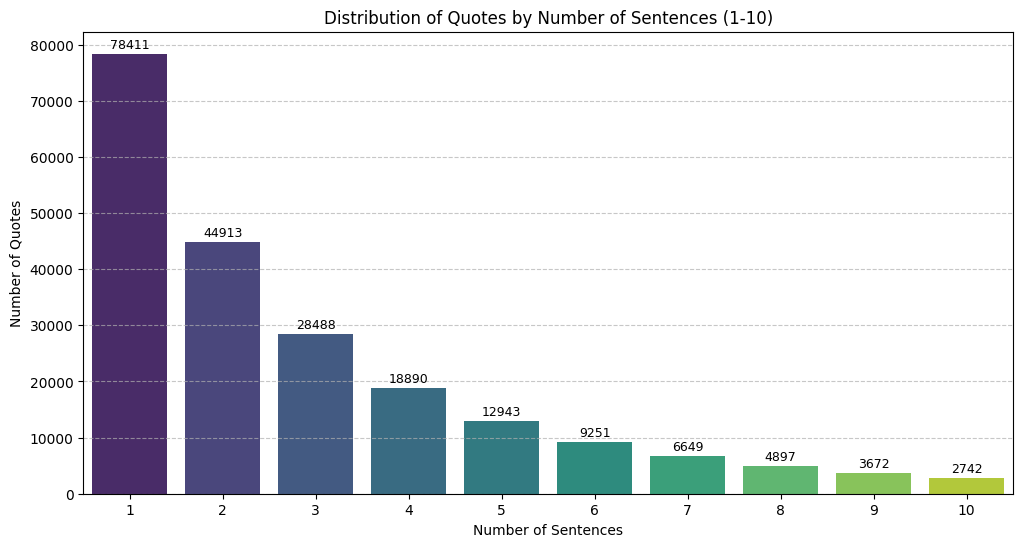


--- Examples from each sentence count category ---

----------
| 1 SENTENCE(S) |
----------
Example Quote:
"If you want to know what a man's like, take a good look at how he treats his inferiors, not his equals."

Example Quote:
"I am so clever that sometimes I don't understand a single word of what I am saying."


----------
| 2 SENTENCE(S) |
----------
Example Quote:
"Outside of a dog, a book is man's best friend. Inside of a dog it's too dark to read."

Example Quote:
"A reader lives a thousand lives before he dies, said Jojen. The man who never reads lives only one."


----------
| 3 SENTENCE(S) |
----------
Example Quote:
"I am nothing special, of this I am sure. I am a common man with common thoughts and I've led a common life. There are no monuments dedicated to me and my name will soon be forgotten, but I've loved another with all my heart and soul, and to me, this has always been enough.."

Example Quote:
"The story so far:
In the beginning the Universe was created.
This has 

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# This script assumes 'df' is your DataFrame loaded from a previous cell.
if 'df' not in locals() and 'df' not in globals():
    print("Error: DataFrame 'df' not found. Please ensure the cell that loads the data has been run.")
else:
    # --- A Simple and Direct Sentence Splitting Function using Regex ---
    # This is the function that correctly identified the sentence counts.
    def regex_count_sentences(text):
        text = str(text).replace('\\n', '. ').replace('\n', '. ')
        sentences = re.split(r'(?<=[.!?])[\s"]+', text)
        meaningful_sentences = [s for s in sentences if s.strip()]
        return len(meaningful_sentences) if meaningful_sentences else 1

    # Apply the function to the 'QUOTE' column if it hasn't been already.
    if 'sentence_count' not in df.columns:
        df['sentence_count'] = df['QUOTE'].apply(regex_count_sentences)

    # --- Displaying the Distribution ---
    print("--- Distribution of Sentences per Quote ---")
    sentence_distribution = df['sentence_count'].value_counts().sort_index()
    
    sentence_dist_df = sentence_distribution.reset_index()
    sentence_dist_df.columns = ['Number of Sentences', 'Number of Quotes']
    
    total_quotes = len(df)
    sentence_dist_df['Percentage'] = (sentence_dist_df['Number of Quotes'] / total_quotes * 100).map('{:.2f}%'.format)
    
    print(sentence_dist_df[sentence_dist_df['Number of Sentences'] <= 10])
    
    # --- Visualization ---
    print("\n--- Visualizing Sentence Count Distribution ---")
    plt.figure(figsize=(12, 6))
    plot_range = sentence_distribution[sentence_distribution.index <= 10]
    sns.barplot(x=plot_range.index, y=plot_range.values, palette='viridis')
    plt.title('Distribution of Quotes by Number of Sentences (1-10)')
    plt.xlabel('Number of Sentences')
    plt.ylabel('Number of Quotes')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    bar_positions = range(len(plot_range))
    bar_heights = plot_range.values
    for pos, height in zip(bar_positions, bar_heights):
        plt.text(pos, height + 500, str(height), ha='center', va='bottom', fontsize=9)
    plt.show()

    # --- Displaying Examples for Each Sentence Count ---
    print("\n--- Examples from each sentence count category ---")
    pd.set_option('display.max_colwidth', 500) # Widen display to read quotes easily

    # We will show examples for quotes with 1 to 5 sentences.
    for i in range(1, 6):
        print(f"\n----------\n| {i} SENTENCE(S) |\n----------")
        
        # Filter the DataFrame for quotes with 'i' sentences
        examples = df[df['sentence_count'] == i]
        
        if not examples.empty:
            # Display up to 2 examples
            for index, row in examples.head(2).iterrows():
                print(f"Example Quote:\n\"{row['QUOTE']}\"\n")
        else:
            print(f"No quotes found with exactly {i} sentence(s).\n")
            
    pd.reset_option('display.max_colwidth') # Reset display option to default

Total number of unique authors: 5773
Total number of likes across all quotes: 17,193,135

--- Distribution of Likes by Author Tiers ---
  Author Group  Number of Authors % of Total Likes Likes per Author (Avg)
0       Top 1%                 57           61.28%                184,855
1       Top 5%                288           88.19%                 52,647
2      Top 10%                577           95.82%                 28,551
3      Top 25%               1443           99.46%                 11,851
4      Top 50%               2886           99.93%                  5,953
5   Bottom 50%               2887            0.07%                      4


/var/folders/tc/25v4fm995q54360hfh_0nmhw0000gn/T/ipykernel_86732/2951971079.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Author Group', y='% of Total Likes', data=distribution_df, ax=ax1, palette='viridis')


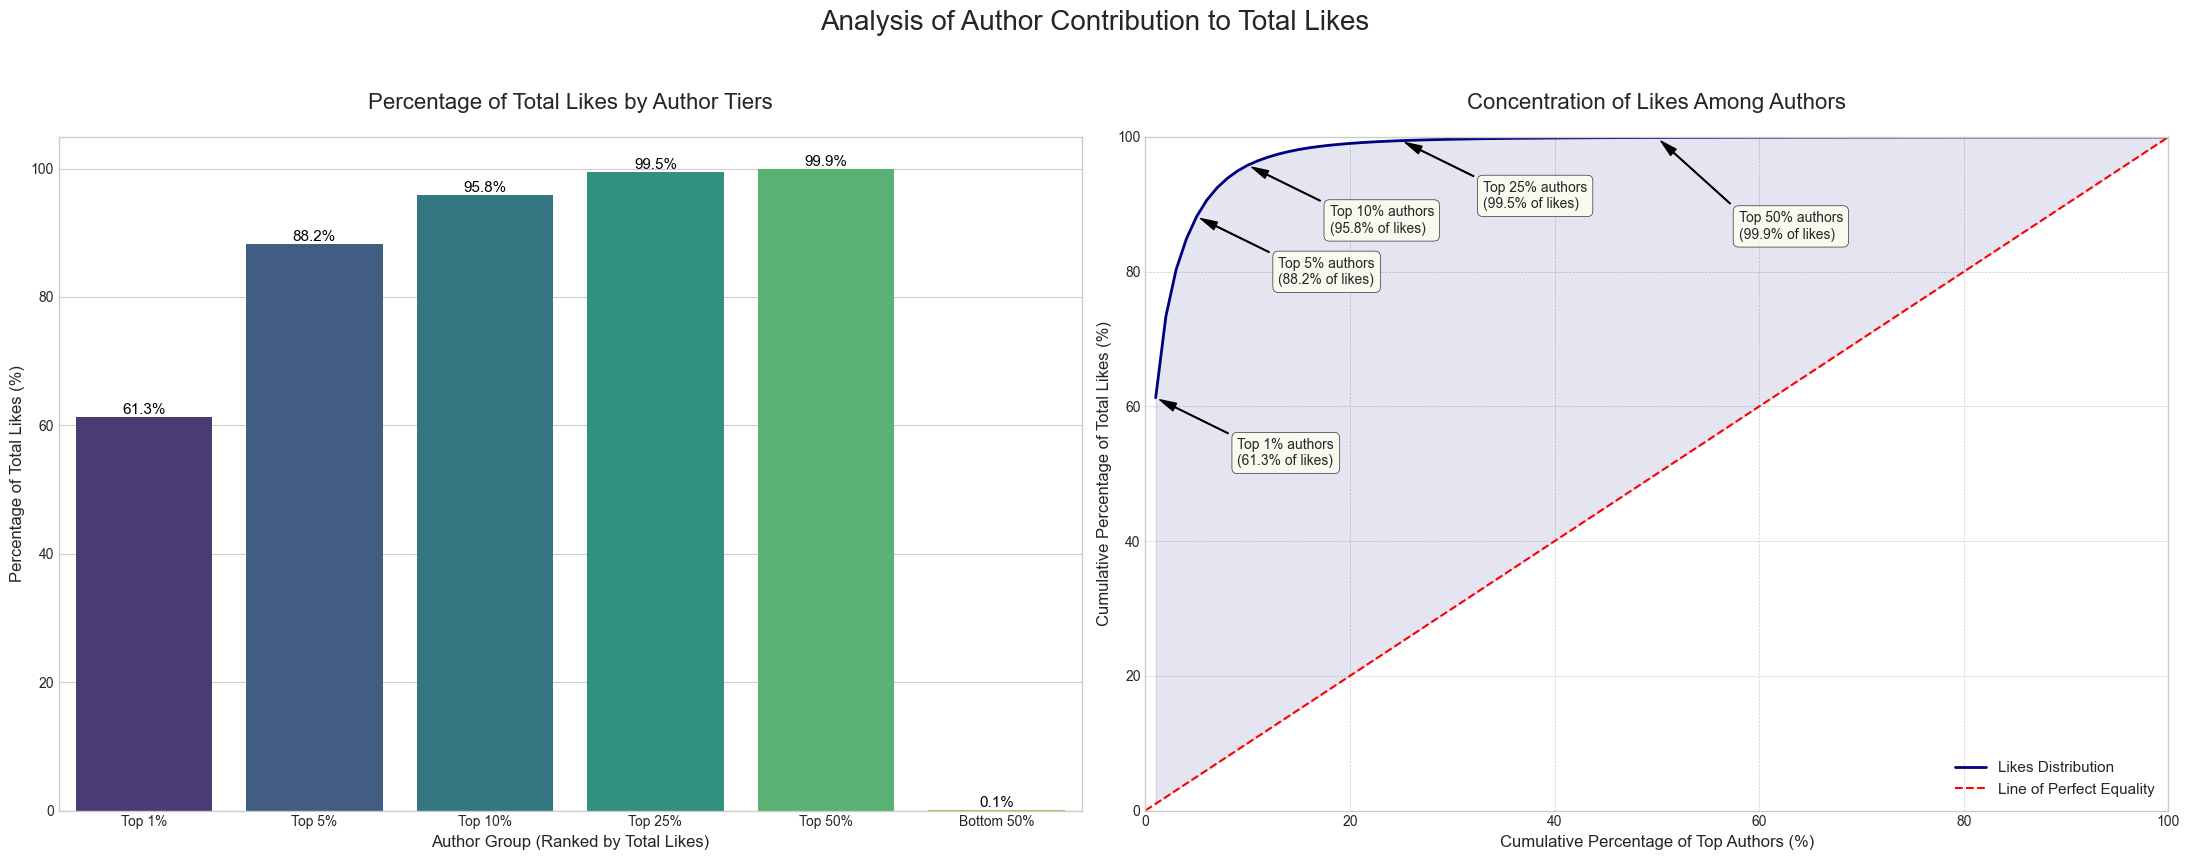

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# This script assumes 'df' is your DataFrame loaded from a previous cell.
# If you run this in a new environment, you'll need to load the data first, for example:
# file_path = '../data/interim/cleaning_data/Data/tags-goodreads-english-popular-quotes.csv'
# df = pd.read_csv(file_path)
# df.columns = df.columns.str.strip()


if 'df' in locals() and not df.empty:
    # --- 1. Calculate total likes per author ---
    # We group by author and sum all their likes across all their quotes.
    author_total_likes = df.groupby('AUTHOR')['LIKES'].sum()

    # --- 2. Sort authors by their total likes in descending order ---
    sorted_authors_by_likes = author_total_likes.sort_values(ascending=False)

    # --- 3. Analyze the distribution ---
    total_likes_overall = sorted_authors_by_likes.sum()
    total_authors = len(sorted_authors_by_likes)

    print(f"Total number of unique authors: {total_authors}")
    print(f"Total number of likes across all quotes: {total_likes_overall:,.0f}\n")

    # --- Data for a summary table ---
    # We'll see what percentage of likes the top tiers of authors hold.
    author_percentiles = {
        'Top 1%': 0.01,
        'Top 5%': 0.05,
        'Top 10%': 0.10,
        'Top 25%': 0.25,
        'Top 50%': 0.50,
    }

    distribution_data = {
        'Author Group': [],
        'Number of Authors': [],
        '% of Total Likes': [],
        'Likes per Author (Avg)': []
    }

    for name, percentile in author_percentiles.items():
        num_authors_in_group = int(total_authors * percentile)
        authors_group = sorted_authors_by_likes.head(num_authors_in_group)
        likes_sum = authors_group.sum()
        likes_percentage = (likes_sum / total_likes_overall) * 100
        
        distribution_data['Author Group'].append(name)
        distribution_data['Number of Authors'].append(num_authors_in_group)
        distribution_data['% of Total Likes'].append(likes_percentage)
        distribution_data['Likes per Author (Avg)'].append(likes_sum / num_authors_in_group)

    # Add the "Bottom 50%" for comparison
    top_50_num = int(total_authors * 0.5)
    bottom_50_num = total_authors - top_50_num
    bottom_50_likes_sum = sorted_authors_by_likes.tail(bottom_50_num).sum()
    bottom_50_likes_percentage = (bottom_50_likes_sum / total_likes_overall) * 100
    distribution_data['Author Group'].append('Bottom 50%')
    distribution_data['Number of Authors'].append(bottom_50_num)
    distribution_data['% of Total Likes'].append(bottom_50_likes_percentage)
    distribution_data['Likes per Author (Avg)'].append(bottom_50_likes_sum / bottom_50_num)

    distribution_df = pd.DataFrame(distribution_data)
    
    print("--- Distribution of Likes by Author Tiers ---")
    print(distribution_df.to_string(formatters={'% of Total Likes':'{:.2f}%'.format, 'Likes per Author (Avg)':'{:,.0f}'.format}))


    # --- 4. Generate data for a more granular Lorenz-like curve ---
    cumulative_authors_percent = np.arange(1, 101) / 100.0
    cumulative_likes_percent = []
    for p in cumulative_authors_percent:
        num_authors = int(total_authors * p)
        if num_authors > 0:
            likes_sum = sorted_authors_by_likes.head(num_authors).sum()
            cumulative_likes_percent.append((likes_sum / total_likes_overall) * 100)
        else:
            cumulative_likes_percent.append(0)

    # --- 5. Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    
    # --- Plot 1: Bar chart for the defined groups ---
    # CORRECTED LINE: Removed redundant `hue` and `dodge` parameters. 
    # The palette is automatically applied to the x-axis categories.
    sns.barplot(x='Author Group', y='% of Total Likes', data=distribution_df, ax=ax1, palette='viridis')
    ax1.set_title('Percentage of Total Likes by Author Tiers', fontsize=16, pad=20)
    ax1.set_xlabel('Author Group (Ranked by Total Likes)', fontsize=12)
    ax1.set_ylabel('Percentage of Total Likes (%)', fontsize=12)
    # The problematic line that tried to remove a non-existent legend is now gone.
    for index, row in distribution_df.iterrows():
        ax1.text(row.name, row['% of Total Likes'], f"{row['% of Total Likes']:.1f}%", 
                 color='black', ha="center", va="bottom", fontsize=11)

    # --- Plot 2: Lorenz-like curve for concentration ---
    ax2.plot(cumulative_authors_percent * 100, cumulative_likes_percent, marker='', linestyle='-', color='navy', lw=2, label='Likes Distribution')
    ax2.plot([0, 100], [0, 100], linestyle='--', color='red', label='Line of Perfect Equality')
    ax2.fill_between(cumulative_authors_percent * 100, cumulative_authors_percent * 100, cumulative_likes_percent, color='navy', alpha=0.1)
    
    ax2.set_title('Concentration of Likes Among Authors', fontsize=16, pad=20)
    ax2.set_xlabel('Cumulative Percentage of Top Authors (%)', fontsize=12)
    ax2.set_ylabel('Cumulative Percentage of Total Likes (%)', fontsize=12)
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.legend(fontsize=11)
    ax2.set_xlim(0, 100)
    ax2.set_ylim(0, 100)

    # Annotate key points on the curve for clarity
    for p in [1, 5, 10, 25, 50]:
        num_authors = int(total_authors * (p/100.0))
        likes_perc = (sorted_authors_by_likes.head(num_authors).sum() / total_likes_overall) * 100
        ax2.annotate(f'Top {p}% authors\n({likes_perc:.1f}% of likes)', 
                     xy=(p, likes_perc), 
                     xytext=(p + 8, likes_perc - 10 if p < 50 else likes_perc - 15),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=6),
                     bbox=dict(boxstyle="round,pad=0.4", fc="ivory", ec="black", lw=0.5, alpha=0.8),
                     fontsize=10)

    plt.suptitle('Analysis of Author Contribution to Total Likes', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("DataFrame 'df' not found or is empty. Please load your data first.")